In [1]:
import math
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image
from statsbombpy import sb
from mplsoccer import VerticalPitch

In [2]:
df=sb.events(match_id=3869685).sort_values(by=['index'])

In [3]:
team1 = df[df.team == 'Argentina']
team2 = df [df.team == 'France']

FRANCE_COLOR = '#002654'
ARGENTINA_COLOR = '#43A1D5'

ARGENTINA_TEAM_ID = 779
FRANCE_TEAM_ID = 771

df = df[df.period < 5]

In [14]:
def create_shotmap(team, ax):
    pitch = VerticalPitch(pitch_type='statsbomb', half=True)
    pitch.draw(ax=ax)

    # the shots data is in the 'type' column
    team = team[team['type' ] == 'Shot' ]

    # Filter down to just the columns we need
    team = team[['team', 'player', 'location', 'shot_outcome', 'shot_statsbomb_xg', 'shot_type']]
    team[['x', 'y']] = team['location'].apply(pd. Series)

    # Draw the shotmap
    for x in team.to_dict(orient='records'):
        pitch.scatter(
            x=x['x'], y=x['y'], ax=ax,
            s=500 * x['shot_statsbomb_xg'],
            color='green' if x['shot_outcome'] == 'Goal' else 'white',
            edgecolors='black', alpha=0.7
            ) 

In [ ]:
def create_passnetwork(team, ax):
    team = team.copy()

    # Get x and y coordinates
    team[['x', 'y']] = team['location'].apply(pd.Series)

    # Get starting lineup / jersey numbers
    tactics = team.loc[~team['tactics'].isnull(), ['tactics', 'team']]

    all_jersey_numbers = []

    for y in tactics.to_dict(orient='records'):
        all_jersey_numbers.append(
            pd.DataFrame([
                {
                    'player_id': x['player']['id'],
                    'jersey_number': x['jersey_number']
                }
                for x in y['tactics']['lineup']
            ])
        )

    jersey_numbers = pd.concat(
        all_jersey_numbers,
        ignore_index=True
    ).drop_duplicates()

    # Create a single time variable
    team['newsecond'] = 60 * team['minute'] + team['second']

    # Sort events chronologically
    team = team.sort_values(by=['newsecond']).copy()

    # Identify passer and recipient
    team['passer'] = team['player_id']
    team['recipient'] = team['passer'].shift(-1)

    # Filter for passes
    passes_df = team.loc[team['type'] == "Pass"].copy()

    # Missing outcome means successful
    passes_df['pass_outcome'] = passes_df['pass_outcome'].fillna("Successful")

    # Successful passes
    completions = passes_df.loc[
        passes_df['pass_outcome'] == "Successful"
    ].copy()

    # Find first substitution
    sub_df = team.loc[team['type'] == "Substitution"]

    first_sub = sub_df['newsecond'].min()

    if first_sub <= (60 * 45):
        first_sub = 60 * 45

    # Keep passes before first substitution
    completions = completions.loc[
        completions['newsecond'] < first_sub
    ].copy()

    # Find average locations
    average_locs_and_count = (
        completions
        .groupby('passer')
        .agg({
            'x': 'mean',
            'y': ['mean', 'count']
        })
    )

    average_locs_and_count.columns = ['x', 'y', 'count']

    # Count passes between each pair of players
    passes_between = (
        completions
        .groupby(['passer', 'recipient'])
        .id.count()
        .reset_index()
    )

    passes_between.rename(
        {'id': 'pass_count'},
        axis='columns',
        inplace=True
    )

    # Add passer's average location
    passes_between = passes_between.merge(
        average_locs_and_count,
        left_on='passer',
        right_index=True
    )

    # Add recipient's average location
    passes_between = passes_between.merge(
        average_locs_and_count,
        left_on='recipient',
        right_index=True,
        suffixes=['', '_end']
    )

    # Only plot combinations with at least 4 passes
    passes_between = passes_between.loc[
        passes_between['pass_count'] >= 4
    ]

    # Function to draw pass lines
    def pass_line_template(ax, x, y, end_x, end_y, line_color):
        ax.annotate(
            '',
            xy=(end_y, end_x),
            xytext=(y, x),
            zorder=1,
            arrowprops=dict(
                arrowstyle='-|>',
                linewidth=4,
                color=line_color,
                alpha=0.85
            )
        )

    # Shrink arrows so they don't overlap nodes
    def pass_line_template_shrink(
        ax, x, y, end_x, end_y, line_color, dist_delta=1.2
    ):
        dist = math.hypot(end_x - x, end_y - y)

        angle = math.atan2(
            end_y - y,
            end_x - x
        )

        upd_x = x + (dist - dist_delta) * math.cos(angle)
        upd_y = y + (dist - dist_delta) * math.sin(angle)

        pass_line_template(
            ax,
            x,
            y,
            upd_x,
            upd_y,
            line_color=line_color
        )

    # Draw pitch
    pitch = VerticalPitch(pitch_type='statsbomb')
    pitch.draw(ax=ax)

    # Plot pass arrows
    for index, row in passes_between.iterrows():
        pass_line_template_shrink(
            ax,
            row['x'],
            row['y'],
            row['x_end'],
            row['y_end'],
            'black'
        )

    # Plot player nodes
    pitch.scatter(
        average_locs_and_count.x,
        average_locs_and_count.y,
        s=500,
        color='#f0ece2',
        edgecolors='#010101',
        linewidth=2,
        alpha=1,
        ax=ax,
        zorder=2
    )

    # Plot jersey numbers
    for index, row in average_locs_and_count.iterrows():

        jersey = jersey_numbers.loc[
            jersey_numbers['player_id'] == row.name,
            'jersey_number'
        ].values

        if len(jersey) > 0:
            pitch.annotate(
                jersey[0],
                xy=(row.x, row.y),
                c='#132743',
                va='center',
                ha='center',
                size=10,
                fontweight='bold',
                ax=ax
            )

In [ ]:
def create_xg_flow_chart(df, ax):
    # Use the original dataframe
    # Filter to only shots
    df = df[df['type'] == 'Shot'].copy()

    # Sort values in chronological order
    df = df.sort_values(by="index")

    # Calculate cumulative xG for each team
    df['cumulative_xG'] = (
        df.groupby('team_id')['shot_statsbomb_xg']
        .cumsum()
    )

    # Plot xG for each team
    # Lines start from 0
    for team in df['team_id'].unique():

        team_df = df[df['team_id'] == team].copy()

        # Add a 0 xG row at the start of the match
        start_row = pd.DataFrame({
            'team_id': [team],
            'minute': [0],
            'shot_statsbomb_xg': [0],
            'shot_outcome': [None],
            'cumulative_xG': [0]
        })

        team_df = pd.concat(
            [start_row, team_df],
            ignore_index=True
        )

        # Plot cumulative xG
        ax.plot(
            team_df['minute'],
            team_df['cumulative_xG'],
            label=team,
            drawstyle='steps-post',
            c=(
                ARGENTINA_COLOR
                if team == ARGENTINA_TEAM_ID
                else FRANCE_COLOR
            ),
            linewidth=2,
            zorder=3
        )

        # Add labels to goals
        goals = team_df[
            team_df['shot_outcome'] == 'Goal'
        ]

        for _, x in goals.iterrows():

            ax.text(
                x['minute'],
                x['cumulative_xG'] - 0.07,
                x['player'],
                ha='center',
                va='center',
                fontfamily='monospace',
                fontsize=8,
                zorder=10
            )

    # Label x-axis with match time
    ax.set_xticks([0, 45, 90, 120])
    ax.set_xticklabels(["0'", "45'", "90'", "120'"])

    # Remove right and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

In [ ]:
def create_table(team1, team2):
    pass

def create_xg_flow_chart(df, ax):
    pass

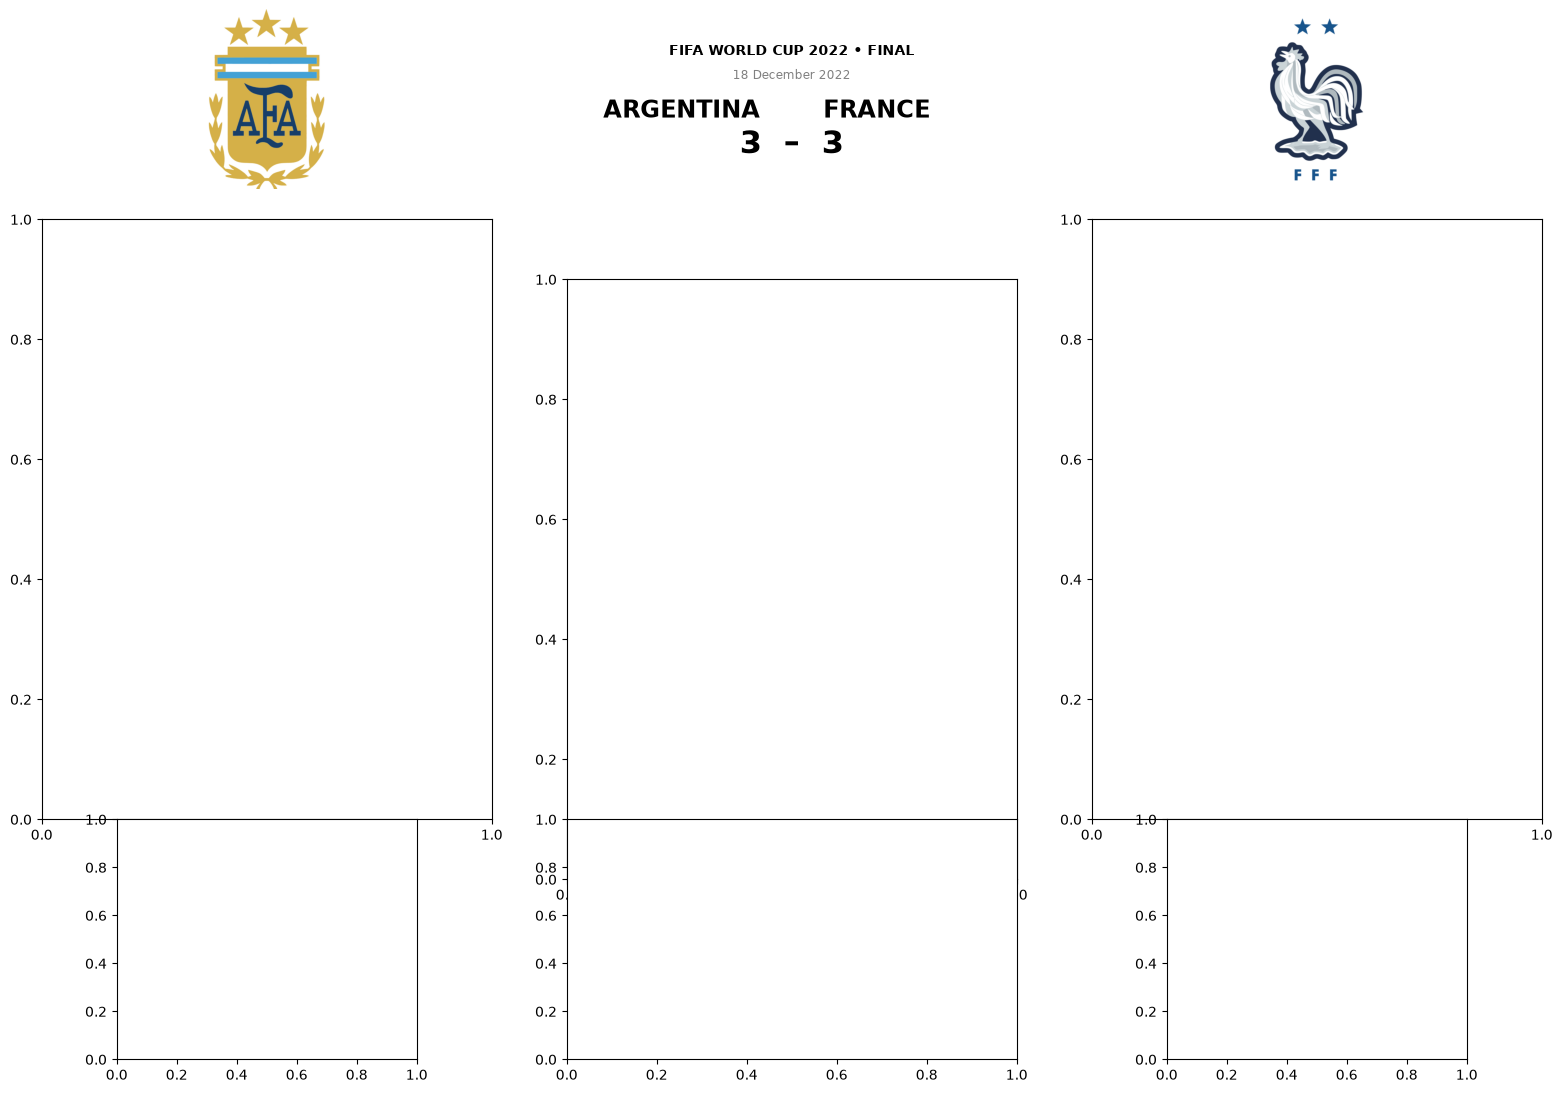

In [13]:
fig = plt.figure(figsize=(15, 12))

ax1 = fig.add_axes([.225, .775, .15, .15])

team1_img = Image.open('D:/Projects/FootballAnalysis1/images/argentina_logo.png')

ax1.imshow(team1_img)
ax1.axis('off')

ax2 = fig.add_axes([.5, .8, .3, .1])
ax2.axis('off')

# Competition
ax2.text(
    .5, .90,
    'FIFA WORLD CUP 2022 • FINAL',
    fontsize=10,
    fontweight='bold',
    ha='center',
    va='center'
)

# Date
ax2.text(
    .5, .70,
    '18 December 2022',
    fontsize=8.5,
    color='gray',
    ha='center',
    va='center'
)

# Teams
ax2.text(
    .43, .40,
    'ARGENTINA',
    fontsize=17,
    fontweight='bold',
    ha='right',
    va='center'
)

ax2.text(
    .57, .40,
    'FRANCE',
    fontsize=17,
    fontweight='bold',
    ha='left',
    va='center'
)

# Score
ax2.text(
    .5, .12,
    '3  –  3',
    fontsize=23,
    fontweight='bold',
    ha='center',
    va='center'
)

ax3 = fig.add_axes([.925, .775, .15, .15])

team2_img = Image.open('D:/Projects/FootballAnalysis1/images/france_logo.png')

ax3.imshow(team2_img)
ax3.axis('off')

ax4 = fig.add_axes( [.15, .25, .3, .5])

ax5 = fig.add_axes([.5, .2, .3, .5])

ax6 = fig.add_axes([.85, .25, .3, .5])
ax7 = fig.add_axes([.2, .05, .2, .2])

ax8 = fig.add_axes([.5, .05, .3, .2])

ax9 = fig.add_axes([.9, .05,.2, .2])